In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [57]:
entropy_all_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/calculated_barcode_entropy_wDNAdebrisflag_df.tsv'
entropy_all = pd.read_csv(entropy_all_file, sep=',', index_col=0)
entropy_all['atac_bc'] = entropy_all.index.str.split('-').str[0]
entropy_all.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT


In [58]:
entropy_all.shape

(33287, 8)

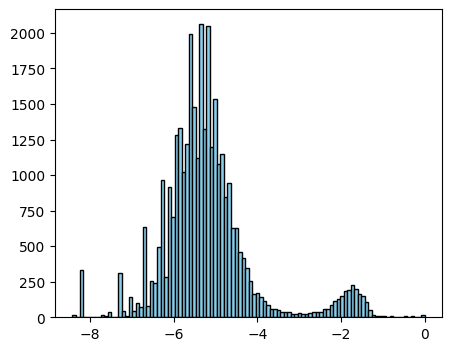

In [59]:
fig, ax = plt.subplots(figsize=(5, 4))
_ = ax.hist(np.log(entropy_all['Entropy']), bins=100, color='skyblue', edgecolor='black')

In [60]:
entropy_w_DNAdebrisflag_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/entropy_filtered_bc_df.tsv'
entropy_w_DNAdebrisflag_df = pd.read_csv(entropy_w_DNAdebrisflag_file, sep=',', index_col=0)
entropy_w_DNAdebrisflag_df['atac_bc'] = entropy_w_DNAdebrisflag_df.index.str.split('-').str[0]
entropy_w_DNAdebrisflag_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG
GGAGGCTTCATGGATA-1,0.969950,0.401102,2468,0.077603,0.925332,0.601704,NO,GGAGGCTTCATGGATA


In [61]:
final_bc_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/entropy_filtered_bc_df.tsv'
entropy_df = pd.read_csv(final_bc_file, sep=',', index_col=0)
entropy_df['atac_bc'] = entropy_df.index.str.split('-').str[0]
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG
GGAGGCTTCATGGATA-1,0.969950,0.401102,2468,0.077603,0.925332,0.601704,NO,GGAGGCTTCATGGATA


In [62]:
frag_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/fragments.tsv'
frag_df = pd.read_csv(frag_file, sep='\t', header=None, names=['chr', 'start', 'end', 'atac_barcodes', 'support'])
frag_df['atac_bc'] = frag_df['atac_barcodes'].str.split('-').str[0]


total_fragments = frag_df.groupby('atac_bc').size().reset_index(name='total_fragments')
total_fragments.set_index('atac_bc', inplace=True)

In [63]:
a = total_fragments.merge(entropy_all, left_index=True, right_on='atac_bc', how='inner')

Text(0.5, 1.0, 'Entropy vs Total Fragments colored by P_closed_state')

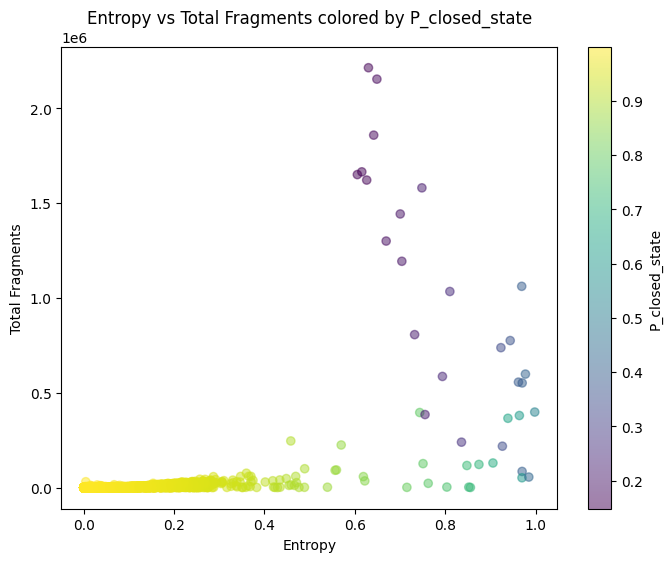

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(a['Entropy'], a['total_fragments'], alpha=0.5, 
           c= a['P_closed_state'])
ax.set_xlabel('Entropy')
ax.set_ylabel('Total Fragments')
# add legend for color
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('P_closed_state')
plt.title('Entropy vs Total Fragments colored by P_closed_state')

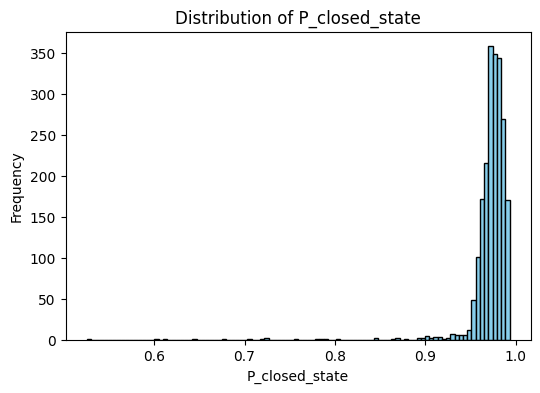

In [65]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(entropy_df['P_closed_state'], bins=100, color='skyblue', edgecolor='black')
ax.set_xlabel('P_closed_state')
ax.set_ylabel('Frequency')
plt.title('Distribution of P_closed_state')
plt.show()

Text(0.5, 1.0, 'P_closed_state vs Entropy colored by Total Fragments')

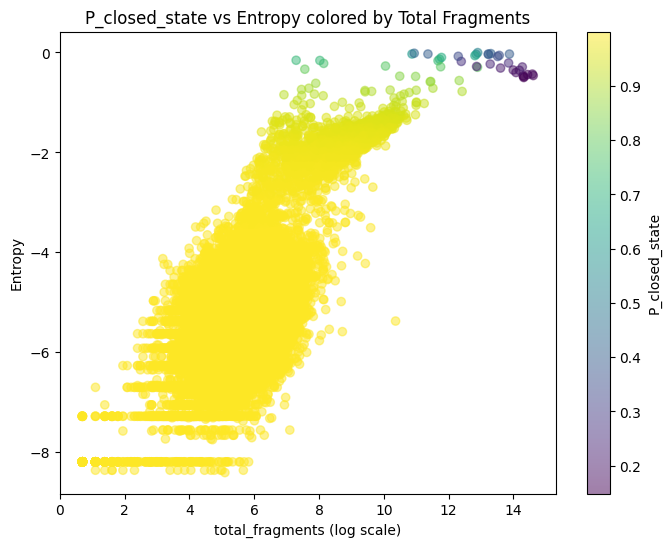

In [66]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter( np.log(a['total_fragments']), np.log(a['Entropy']), alpha=0.5, 
           c = a['P_closed_state'])
ax.set_xlabel('total_fragments (log scale)')
ax.set_ylabel('Entropy')
# add legend for color
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('P_closed_state')
plt.title('P_closed_state vs Entropy colored by Total Fragments')


TCCTCCATCAGGTTCC-1
total_fragments                   56264
Entropy                        0.985064
Entropy_open_region            0.500669
Mp                                 4760
mle_lambda                     0.105701
P0_open_region                 0.899693
P_closed_state                 0.428163
DNA_debris                          YES
atac_bc                TCCTCCATCAGGTTCC
Name: TCCTCCATCAGGTTCC-1, dtype: object


KeyError: 'width'

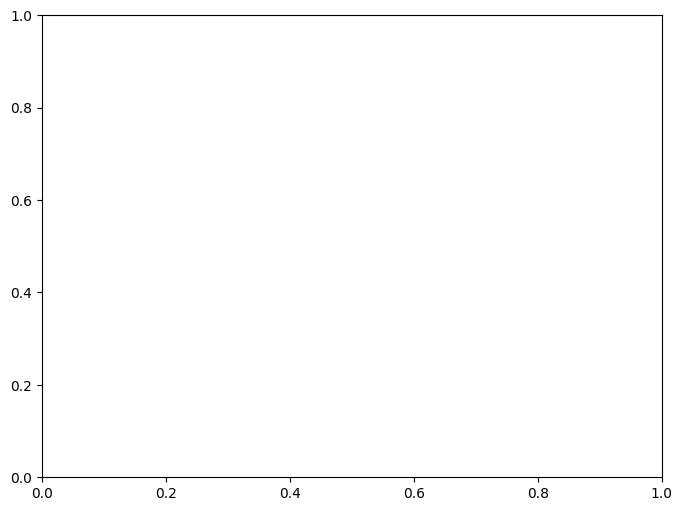

In [67]:
bc = a[(a['Entropy'] > 0.98) & (a['P_closed_state'] < 0.5)].index[0]
print(bc)
print(a.loc[bc])

fig, ax = plt.subplots(figsize=(8, 6))
_ = ax.hist(frag_df[frag_df['atac_bc'] == bc]['width'], bins=50, color='skyblue', edgecolor='black')

In [68]:
(np.log(a['total_fragments']) >= 12).sum()

np.int64(28)

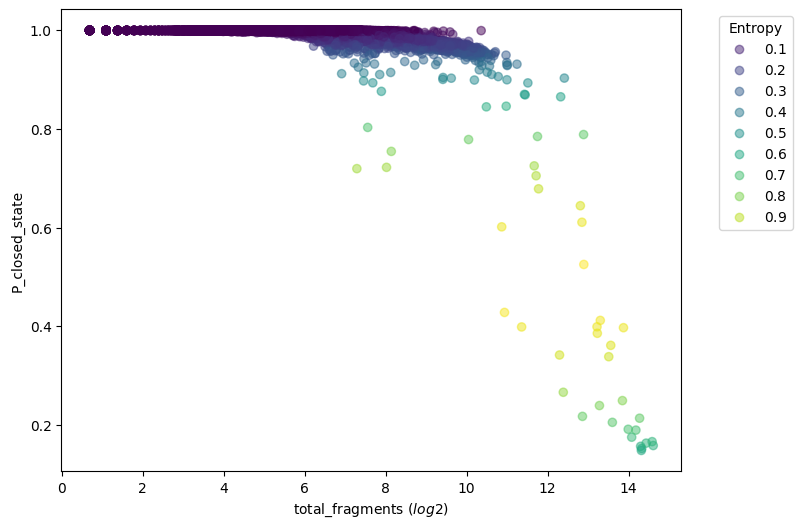

In [71]:
fig, ax = plt.subplots(figsize=(8, 6))
v1 = ax.scatter(np.log(a['total_fragments']), a['P_closed_state'], alpha=0.5,
                c = a['Entropy'],)
ax.set_xlabel('total_fragments ($log2$)')
ax.set_ylabel('P_closed_state')
ax.legend(*v1.legend_elements(), title='Entropy', bbox_to_anchor=(1.05, 1), loc='upper left')

In [22]:
union_cell_info_file = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/Union_cell_3set.tsv'
union_cell_info = pd.read_csv(union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)



,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy
atac_bc,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451


In [48]:
union_cell_info['P_closed_state'] = union_cell_info.index.map(entropy_df.set_index('atac_bc')['P_closed_state'])

Text(0, 0.5, 'P_closed_state')

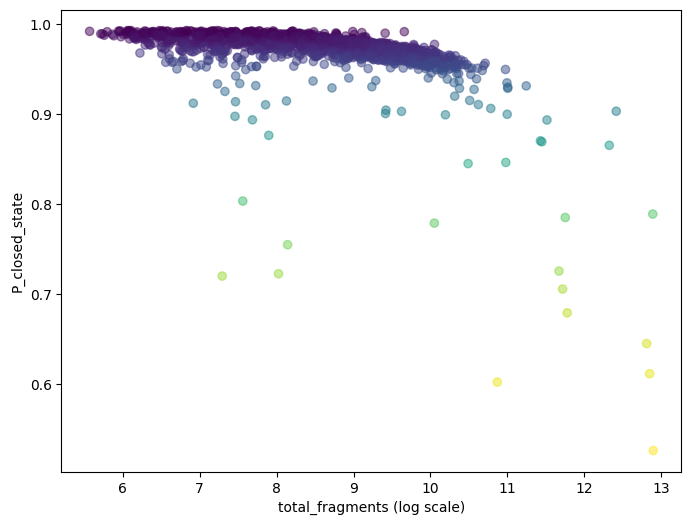

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))
v1 = ax.scatter(np.log(union_cell_info['total_fragments']), union_cell_info['P_closed_state'], alpha=0.5,
                c = union_cell_info['Entropy'],)
ax.set_xlabel('total_fragments (log scale)')
ax.set_ylabel('P_closed_state')

Text(0, 0.5, 'P_closed_state')

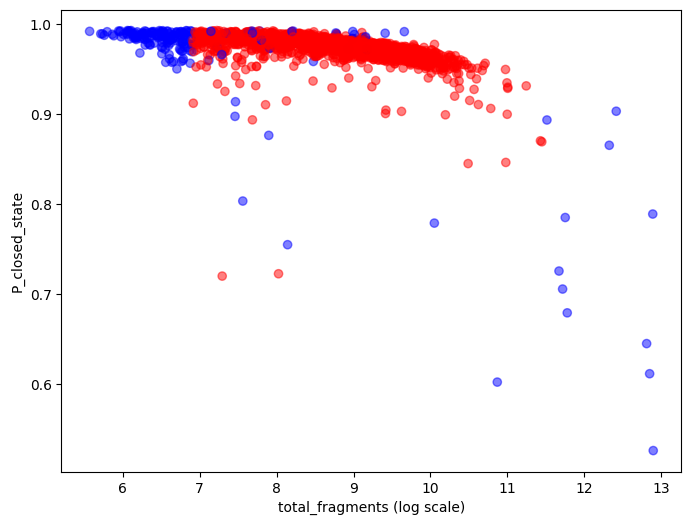

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))
v1 = ax.scatter(np.log(union_cell_info['total_fragments']), union_cell_info['P_closed_state'], alpha=0.5,
                c = union_cell_info['atac_pass_archr_TSS'].map({True: 'red', False: 'blue'}),)
ax.set_xlabel('total_fragments (log scale)')
ax.set_ylabel('P_closed_state')

In [51]:
union_cell_info.groupby(['atac_pass_entropy', 'atac_pass_archr_TSS']).size().unstack()

atac_pass_archr_TSS,False,True
atac_pass_entropy,,
False,61,222
True,191,1910


In [52]:
union_cell_info['stringent_cell_calling'] = union_cell_info['P_closed_state'] > 0.8

union_cell_info.groupby(['stringent_cell_calling', 'atac_pass_archr_TSS']).size().unstack()

atac_pass_archr_TSS,False,True
stringent_cell_calling,,
False,72,224
True,180,1908


In [53]:
union_cell_info.groupby(['stringent_cell_calling', 'atac_pass_entropy']).size().unstack()

atac_pass_entropy,False,True
stringent_cell_calling,,
False,283.0,13.0
True,NaN,2088.0


In [55]:
union_cell_info.to_csv('/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/Union_cell_3set_with_stringent_calling.tsv', sep='\t')

TCCTCCATCAGGTTCC-1  Entropy:0.9851  P_closed_state:0.4282  total_fragments:56264
CAAACAATCAGCCTGT-1  Entropy:0.9776  P_closed_state:0.4120  total_fragments:599072
AGCTTCCAGCTTACTG-1  Entropy:0.9704  P_closed_state:0.3991  total_fragments:552356
CAACATAAGCAAGGAA-1  Entropy:0.9702  P_closed_state:0.3987  total_fragments:85870
GTGAACAGTTGACTAC-1  Entropy:0.9693  P_closed_state:0.3972  total_fragments:1061735
GTCCAAACACACAAGC-1  Entropy:0.9621  P_closed_state:0.3859  total_fragments:556685
TGCGCCTCATCCTGCA-1  Entropy:0.9439  P_closed_state:0.3614  total_fragments:775783
CTCAGCTAGCAGGTTG-1  Entropy:0.9266  P_closed_state:0.3418  total_fragments:218950
TCAACAAAGACTCCTA-1  Entropy:0.9233  P_closed_state:0.3384  total_fragments:738340
CATTATCAGGAGCAGG-1  Entropy:0.8360  P_closed_state:0.2662  total_fragments:240234
ACCGGCTGTTGTTCCC-1  Entropy:0.8103  P_closed_state:0.2494  total_fragments:1034446
CTAGTAGCAAATAAGG-1  Entropy:0.7939  P_closed_state:0.2393  total_fragments:586613
TCCTCCTCAGTGTGCG

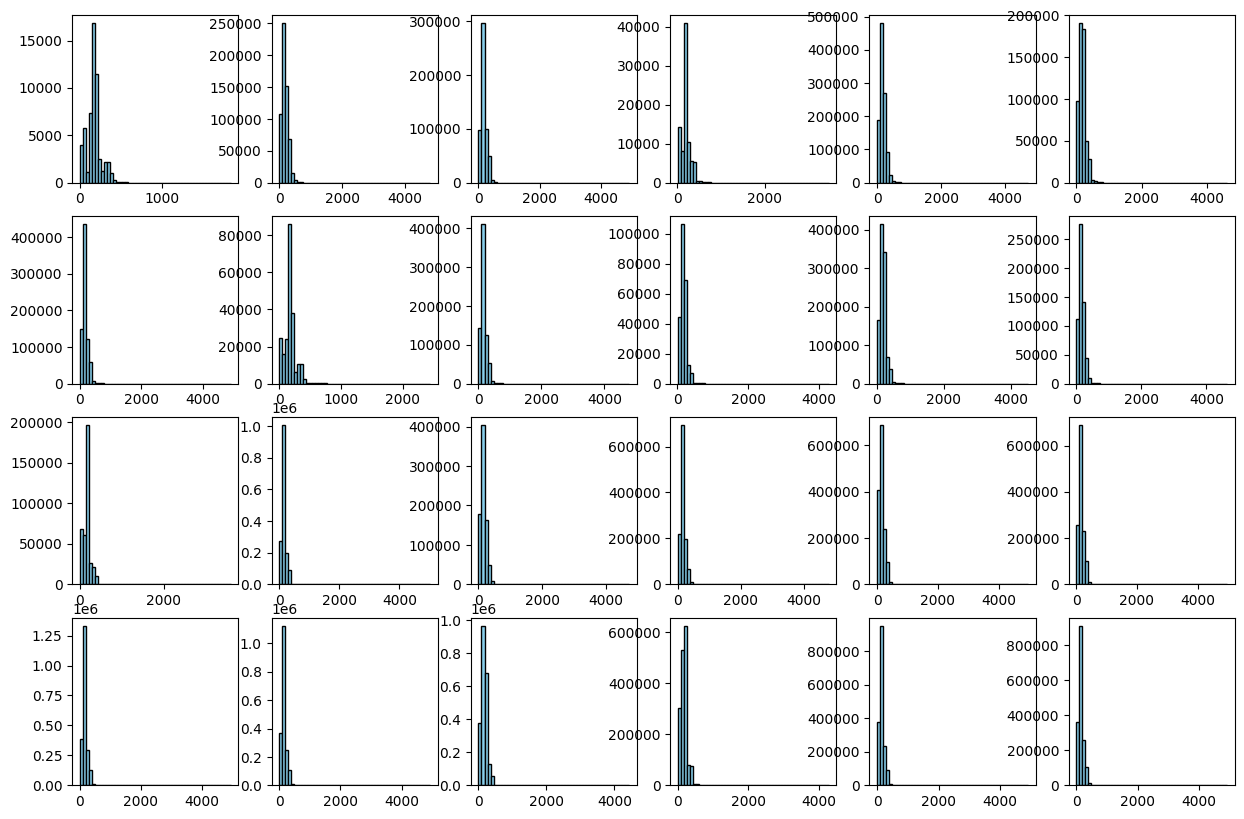

In [66]:
fig, ax = plt.subplots(ncols=6, nrows=4, figsize=(15, 10))
ax = ax.flatten()

for i, x in enumerate(ax):
    bc = excessive_reads_bc[i]
    print(f"{bc}  Entropy:{a.loc[bc, 'Entropy']:.4f}  P_closed_state:{a.loc[bc, 'P_closed_state']:.4f}  total_fragments:{a.loc[bc, 'total_fragments']}")
    _ = x.hist(frag_df[frag_df['atac_bc'] == bc]['width'], bins=50, color='skyblue', edgecolor='black')


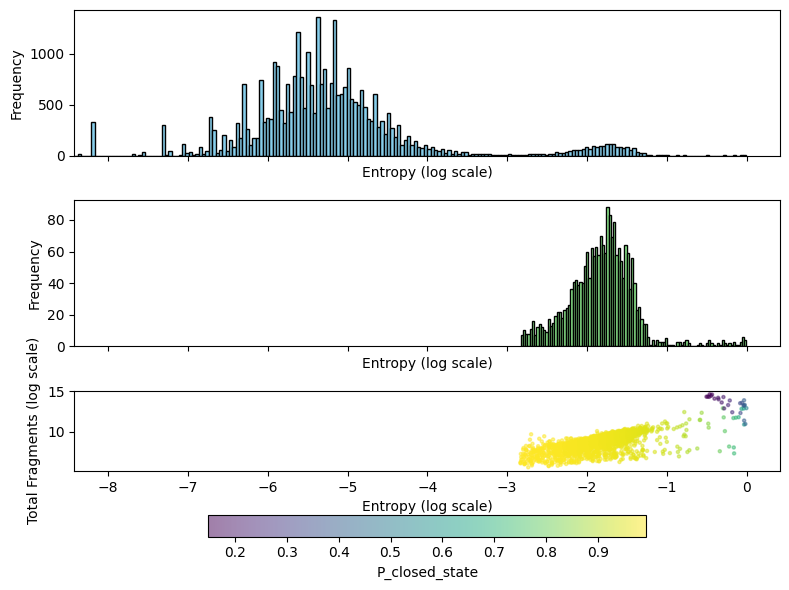

In [143]:
fig, ax = plt.subplots(figsize=(8, 6), nrows=3, ncols=1, sharex=True)
xlims = min(np.log(entropy_all['Entropy'].min()), np.log(entropy_df['Entropy'].min()))

_ = ax[0].hist(np.log(entropy_all['Entropy']), bins=200, color='skyblue', edgecolor='black')
_ = ax[1].hist(np.log(entropy_df['Entropy']), bins=100, color='lightgreen', edgecolor='black')


ax[0].set_xlabel('Entropy (log scale)')
ax[0].set_ylabel('Frequency')

ax[1].set_xlabel('Entropy (log scale)')
ax[1].set_ylabel('Frequency')

ax[2].scatter(np.log(a['Entropy']),
              np.log(a['total_fragments']),
                alpha=0.5, s= 5,
                c=a['P_closed_state'])
ax[2].set_xlabel('Entropy (log scale)')
ax[2].set_ylabel('Total Fragments (log scale)')
ax[2].set_xlim(xlims)
cbar = plt.colorbar(ax[2].collections[0], ax=ax[2],orientation="horizontal", pad=0.3,)
cbar.set_label('P_closed_state')
plt.tight_layout()


Text(0, 0.5, 'Frequency')

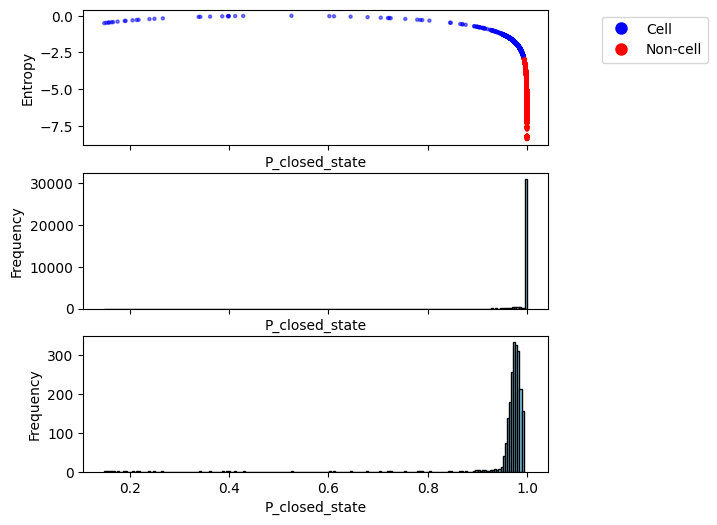

In [ ]:
fig, ax = plt.subplots(nrows=3, figsize=(6, 6), sharex=True)
entropy_all['cell'] = entropy_all['Entropy'] >= entropy_df['Entropy'].min()
ax[0].scatter(entropy_all['P_closed_state'], np.log(entropy_all['Entropy']),  alpha=0.5,
           c=entropy_all['cell'].map({True: 'blue', False: 'red'}), 
           s = 5)
ax[0].set_ylabel('Entropy')
ax[0].set_xlabel('P_closed_state')
ax[0].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Cell', markerfacecolor='blue', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Non-cell', markerfacecolor='red', markersize=10)], 
          bbox_to_anchor=(1.1, 1), loc='upper left')

_ = ax[1].hist(entropy_all['P_closed_state'], bins=200, color='skyblue', edgecolor='black')
ax[1].set_xlabel('P_closed_state')
ax[1].set_ylabel('Frequency')

_ = ax[2].hist(entropy_df['P_closed_state'], bins=200, color='skyblue', edgecolor='black')
ax[2].set_xlabel('P_closed_state')
ax[2].set_ylabel('Frequency')

In [ ]:
union_cell_df_file='/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F/_cell_calling_comparison/Union_cell_3set.tsv'
Union_cell_df = pd.read_csv(union_cell_df_file, sep='\t')
Union_cell_df.index = Union_cell_df['atac_bc'] + '-1'

Union_cell_df.head(2)